In [1]:
# packages
import duckdb
import pandas as pd

In [2]:
con = duckdb.connect("../guardian_articles.duckdb")

# Preview some cleaned articles
con.execute("SELECT id, webtitle, clean_body FROM cleaned_articles LIMIT 5").fetchdf()

,id,webTitle,clean_body
0,commentisfree/2026/feb/22/the-guardian-view-on...,The Guardian view on the funding crisis at the...,“The National Gallery is doing a great job is...
1,australia-news/2026/feb/23/ai-chatbots-schools...,"In some schools, chatbots interrogate students...","Once upon a time, school students would submit..."
2,world/2026/feb/22/erik-prince-drone-company-uk...,Blackwater founder Erik Prince has joined the ...,After multiple sources previously told the Gua...
3,sport/2026/feb/22/the-great-olympic-lie-untold...,The Great Olympic lie: untold story of Winter ...,"On the foothills of the mountains, by the bank..."
4,uk-news/2026/feb/22/governments-response-to-ma...,Government’s response to Maccabi Tel Aviv fan ...,The government’s response to West Midlands pol...


In [3]:
df_counts = con.execute("SELECT COUNT (DISTINCT ID) FROM cleaned_articles").fetchdf()
print(df_counts)


   count(DISTINCT ID)
0               24124


In [4]:
# load table
df = con.execute("SELECT * FROM cleaned_articles").fetchdf()

# compute missing counts and percentages
missing_summary = pd.DataFrame(
    {"missing_count": df.isna().sum(), "missing_pct": 100 * df.isna().mean()}
).sort_values(by="missing_pct", ascending=False)

print(missing_summary)

                    missing_count  missing_pct
pillarName                    227     0.940972
pillarId                      227     0.940972
id                              0     0.000000
isHosted                        0     0.000000
pull_date                       0     0.000000
search_term                     0     0.000000
shortUrl                        0     0.000000
headline                        0     0.000000
body                            0     0.000000
type                            0     0.000000
apiUrl                          0     0.000000
webUrl                          0     0.000000
webTitle                        0     0.000000
webPublicationDate              0     0.000000
sectionName                     0     0.000000
sectionId                       0     0.000000
clean_body                      0     0.000000


In [7]:
pd.crosstab(
    df["pillarName"].isna(),
    df["pillarId"].isna(),
    rownames=["pillarName_missing"],
    colnames=["pillarId_missing"],
)

pillarId_missing,False,True
pillarName_missing,,
False,23897,0
True,0,227


In [42]:
# looking into missing vars "pillarName" and "pillarId"

In [5]:
# look at most common variables
top5 = (
    df.groupby(["pillarName", "pillarId", "sectionId", "sectionName"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

print(top5)


   pillarName          pillarId                                 sectionId  \
44       News       pillar/news                                technology   
52    Opinion    pillar/opinion                             commentisfree   
51       News       pillar/news                                     world   
48       News       pillar/news                                   us-news   
18       News       pillar/news                            australia-news   
19       News       pillar/news                                  business   
1        Arts       pillar/arts                                     books   
4        Arts       pillar/arts                                      film   
37       News       pillar/news                                  politics   
24       News       pillar/news                               environment   
53      Sport      pillar/sport                                  football   
0        Arts       pillar/arts                              artanddesign   

In [6]:
# counts by type
counts = df["type"].value_counts()
shares = df["type"].value_counts(normalize=True)

summary = pd.concat([counts, shares], axis=1)
summary.columns = ["count", "share"]

print(summary)

             count     share
type                        
article      22095  0.915893
liveblog      1903  0.078884
interactive    122  0.005057
audio            3  0.000124
picture          1  0.000041


In [45]:
counts_pillarName = df["pillarName"].value_counts()
shares_pillarName = df["pillarName"].value_counts(normalize=True)

summary_pillarName = pd.concat([counts_pillarName, shares_pillarName], axis=1)
summary_pillarName.columns = ["count", "share"]

print(summary_pillarName)

            count     share
pillarName                 
News        14182  0.593464
Arts         4796  0.200695
Opinion      2211  0.092522
Lifestyle    1375  0.057539
Sport        1333  0.055781


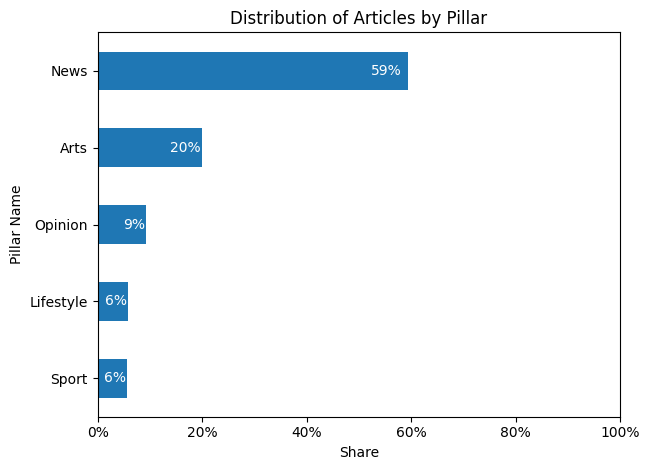

In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Calculate shares
shares = df["pillarName"].value_counts(normalize=True, dropna=True)

# Sort for horizontal bar chart
shares = shares.sort_values()

plt.figure()
ax = shares.plot(kind="barh")

plt.xlabel("Share")
plt.ylabel("Pillar Name")
plt.title("Distribution of Articles by Pillar")


# data labels
for i, v in enumerate(shares):
    ax.text(
        v * 0.98,
        i,
        f"{v:.0%}",
        va="center",
        ha="right",
        color="white",
    )

plt.tight_layout()
# fixing a axis labels and limits
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 1)

plt.show()

In [9]:
# Calculate shares
shares = (
    df["sectionName"].value_counts(normalize=True, dropna=True).head(10).sort_values()
)
# Sort for horizontal bar chart
shares = shares.sort_values().head(10)

plt.figure()
ax = shares.plot(kind="barh")

plt.xlabel("Share")
plt.ylabel("Section Name")
plt.title("Distribution of Articles by Section")


# data labels
for i, v in enumerate(shares):
    ax.text(
        v * 0.98,
        i,
        f"{v:.0%}",
        va="center",
        ha="right",
        color="white",
    )

plt.tight_layout()
# fixing a axis labels and limits
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 0.5)

plt.show()

NameError: name 'plt' is not defined

In [48]:
# calculate number of articles per year

df["webPublicationDate"] = pd.to_datetime(df["webPublicationDate"])
df["year"] = df["webPublicationDate"].dt.year
articles_by_year = df["year"].value_counts().sort_index()

print(articles_by_year)

year
2016    1625
2017    1896
2018    1740
2019    1612
2020    1491
2021    1480
2022    1579
2023    3261
2024    3611
2025    4896
2026     933
Name: count, dtype: int64


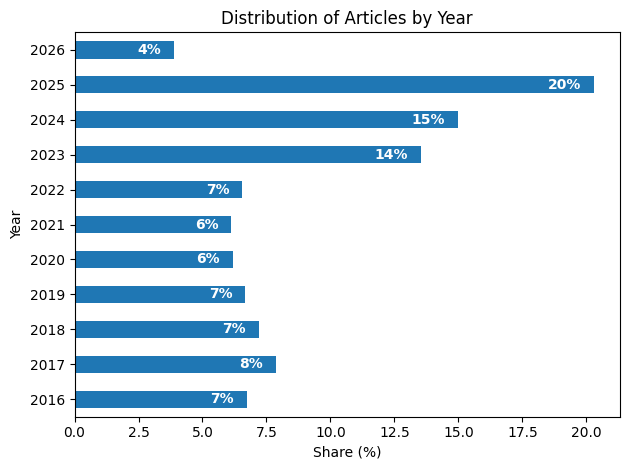

In [ ]:
# plotting number of articles by year
summary_year = df["year"].value_counts().sort_index(ascending=False).to_frame("Count")
summary_year["Share (%)"] = (
    summary_year["Count"] / summary_year["Count"].sum() * 100
).round(2)

plt.figure()
ax = summary_year["Share (%)"].plot(kind="barh")

plt.xlabel("Share (%)")
plt.ylabel("Year")
plt.title("Distribution of Articles by Year")

# data labels
for i, v in enumerate(summary_year["Share (%)"]):
    ax.text(
        v - 0.5,  # just inside the end of the bar
        i,
        f"{v:.0f}%",
        va="center",
        ha="right",
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
ax.set_xlim(0, summary_year["Share (%)"].max() * 1.05)
plt.show()

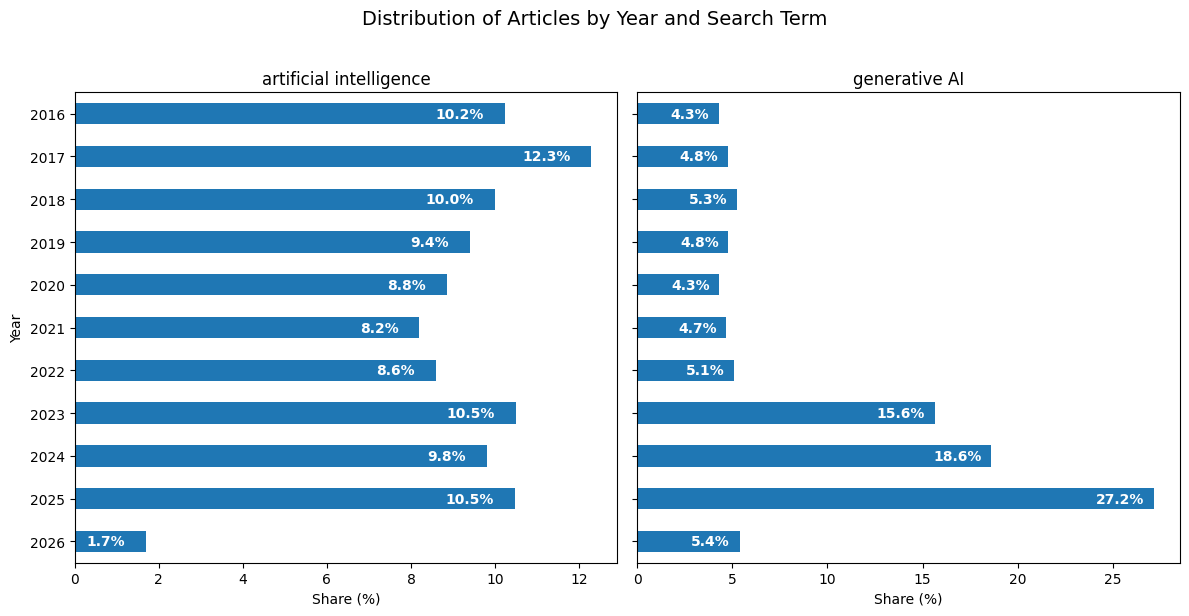

In [65]:
search_terms = df["search_term"].unique()
n = len(search_terms)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), sharey=True)

for ax, term in zip(axes, search_terms):
    subset = df[df["search_term"] == term]
    summary = (
        subset["year"].value_counts().sort_index(ascending=False).to_frame("Count")
    )
    summary["Share (%)"] = (summary["Count"] / summary["Count"].sum() * 100).round(2)

    summary["Share (%)"].plot(kind="barh", ax=ax)

    for i, v in enumerate(summary["Share (%)"]):
        ax.text(
            v - 0.5,
            i,
            f"{v:.1f}%",
            va="center",
            ha="right",
            color="white",
            fontweight="bold",
        )

    ax.set_title(term)
    ax.set_xlabel("Share (%)")
    ax.set_ylabel("Year")
    ax.set_xlim(0, summary["Share (%)"].max() * 1.05)

plt.suptitle("Distribution of Articles by Year and Search Term", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Close connection
con.close()